## 1. Kurulum ve Bağımlılıklar

## ⚙️ Konfigürasyon — Sadece bu hücreyi değiştir!
Farklı bir branch veya dataset için **yalnızca aşağıdaki hücreyi** güncelle. Geri kalan tüm hücreler buradan okur.


In [48]:
# ============================================================
# PROJE KONFİGÜRASYONU — Branch değiştirince sadece burayı güncelle
# ============================================================

# --- GitHub & Drive ---
REPO_URL        = "https://github.com/panzerofthelake03/DiffuVQA.git"
BRANCH          = "PubMedBERT"
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/DiffuVQA"
LOCAL_CLONE_PATH   = "/content/DiffuVQA"

# --- Model ---
MODEL_NAME      = "pubmedbert"
MODEL_LABEL     = "DiffuVQA-PubMedBERT"

# --- Dataset ---
DATASET         = "SLAKE"
DATA_DIR        = "datasets"
IMAGEFOLDER_NAME = "SLAKE/imgs"
DRIVE_IMAGE_DIR = f"{DRIVE_PROJECT_PATH}/datasets/SLAKE/imgs"
LOCAL_IMAGE_DIR = f"{LOCAL_CLONE_PATH}/datasets/SLAKE/imgs"

DATASET_IMG_PATHS = [
    f"/content/drive/MyDrive/datasets/SLAKE/imgs",
    f"/content/drive/MyDrive/DiffuVQA/datasets/SLAKE/imgs",
    f"/content/drive/Drive'ım/DiffuVQA/datasets/SLAKE/imgs",
]

# --- Donanım ---
# T4 GPU  : BATCH_SIZE=8,  MICROBATCH=8,  LR=0.0001
# A100 GPU: BATCH_SIZE=64, MICROBATCH=16, LR=0.000283 (sqrt scaling)
#
# LR sqrt scaling: base_lr * sqrt(batch / base_batch)
#   = 0.0001 * sqrt(64 / 8) = 0.0001 * 2.828 = 0.000283
#
# Microbatch=16: 64 örneği 4 parçada işler → gradient accumulation

BASE_BATCH      = 8
BASE_LR         = 0.0001

import math
BATCH_SIZE      = 64
MICROBATCH      = 16
LR              = round(BASE_LR * math.sqrt(BATCH_SIZE / BASE_BATCH), 6)  # 0.000283

# --- Eğitim ---
# SLAKE ~4500 train örneği. Batch 64 → ~70 step/epoch.
# 150000 step ≈ ~2142 epoch. A100'de yaklaşık 24-30 saat (ara ara resume ile).
# DIFFUSION_STEPS=2000: orijinal DiffuSeq konfigürasyonu.
# SAVE_INTERVAL=5000: 30 checkpoint kaydedilir (150k/5k), her birinden resume yapılabilir.
# LR schedule: cosine decay — lineer'den farklı olarak erken adımlarda LR yüksek kalır.
LEARNING_STEPS  = 250000
DIFFUSION_STEPS = 2000
SEQ_LEN         = 32
HIDDEN_T_DIM    = 768
SEED            = 42
SAVE_INTERVAL   = 5000
LOG_INTERVAL    = 100

# --- Yeni Diffusion Karar Bayrakları ---
# Training/Inference hizası için varsayılan: False (önerilen)
# True yaparsan noising branch'e cond_x_start enjekte edilir (ablasyon).
USE_NOISING_F = False

# pre_answer_loss varsayılan: 0.0 (kapalı, önerilen).
# 0.05 gibi değerlerle fusion supervision ablation yapılabilir.
PRE_ANSWER_LOSS_WEIGHT = 0.0

# --- Sampling ---
# DDIM: DIFFUSION_STEPS=2000 adımı SAMPLE_STEP=200'e indirir (10x hızlanma)
SAMPLE_STEP     = 200

# --- Checkpoint & Çıktı ---
CHECKPOINT_PATH = f"/content/drive/MyDrive/DiffuVQA/checkpoints/{DATASET.lower()}/{MODEL_NAME.lower()}/btch{BATCH_SIZE}/lr{LR}"
SAMPLE_FOLDER   = f"/content/drive/MyDrive/DiffuVQA/samples/{DATASET.lower()}/{MODEL_NAME.lower()}"
OUTPUT_CSV      = f"./reports/{MODEL_NAME}_{DATASET.lower()}_evaluation_results.csv"
DRIVE_RESULTS_PATH = "/content/drive/MyDrive/DiffuVQA_Results/"


# --- Resume (isteğe bağlı) ---
# Ara checkpointten devam etmek için EMA checkpoint yolunu gir.
# None bırakırsan sıfırdan eğitim başlar.
# Örnek: "/content/drive/MyDrive/DiffuVQA/checkpoints/slake/pubmedbert/btch64/lr0.000283/ema_0.9999_020000.pt"
RESUME_CHECKPOINT = "/content/drive/MyDrive/DiffuVQA/checkpoints/slake/pubmedbert/btch64/lr0.000283/ema_0.9999_225000.pt" # sıfırdan başlamak için None bırak

print("✅ Konfigürasyon yüklendi:")
print(f"   Branch    : {BRANCH}  →  {REPO_URL}")
print(f"   Model     : {MODEL_NAME} | Dataset: {DATASET}")
print(f"   Batch: {BATCH_SIZE} | Microbatch: {MICROBATCH} | LR: {LR} (sqrt scaled from {BASE_LR})")
print(f"   Steps: {LEARNING_STEPS} | DiffSteps: {DIFFUSION_STEPS} | SeqLen: {SEQ_LEN}")
print(f"   Save: {SAVE_INTERVAL} | Log: {LOG_INTERVAL} | Sample: {SAMPLE_STEP} (DDIM)")
print(f"   use_noising_f: {USE_NOISING_F} | pre_answer_loss_weight: {PRE_ANSWER_LOSS_WEIGHT}")
print(f"   Checkpoint: {CHECKPOINT_PATH}")
print(f"   Resume    : {RESUME_CHECKPOINT or 'None (sıfırdan eğitim)'}")


✅ Konfigürasyon yüklendi:
   Branch    : PubMedBERT  →  https://github.com/panzerofthelake03/DiffuVQA.git
   Model     : pubmedbert | Dataset: SLAKE
   Batch: 64 | Microbatch: 16 | LR: 0.000283 (sqrt scaled from 0.0001)
   Steps: 250000 | DiffSteps: 2000 | SeqLen: 32
   Save: 5000 | Log: 100 | Sample: 200 (DDIM)
   use_noising_f: False | pre_answer_loss_weight: 0.0
   Checkpoint: /content/drive/MyDrive/DiffuVQA/checkpoints/slake/pubmedbert/btch64/lr0.000283
   Resume    : /content/drive/MyDrive/DiffuVQA/checkpoints/slake/pubmedbert/btch64/lr0.000283/ema_0.9999_225000.pt


In [ ]:
# GPU kontrolü
!nvidia-smi

Thu May 21 12:31:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             44W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [49]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
import os
import shutil

os.chdir("/content")  # cwd'yi güvenli dizine al, sonra rmtree yapılabilir

# ADIM 1: Colab'daki geçici klasörü temizle (Taze indirme için şart)
if os.path.exists(LOCAL_CLONE_PATH):
    print(f"Eski geçici klasör siliniyor: {LOCAL_CLONE_PATH}")
    shutil.rmtree(LOCAL_CLONE_PATH)

# ADIM 2: GitHub'dan en güncel hali çek
print("GitHub'dan taze kopya çekiliyor...")
!git clone -b {BRANCH} --single-branch {REPO_URL} {LOCAL_CLONE_PATH}

# ADIM 3: Drive'a SADECE KOD DOSYALARINI kopyala
# datasets/ ve checkpoints/ klasörlerine DOKUNMA — Drive'daki veriler silinir
print(f"Drive'daki kod dosyaları güncelleniyor: {DRIVE_PROJECT_PATH}")
if not os.path.exists(DRIVE_PROJECT_PATH):
    os.makedirs(DRIVE_PROJECT_PATH)

SKIP_DIRS = {"datasets", "checkpoints", "samples", "outputs", "reports", ".git"}
for item in os.listdir(LOCAL_CLONE_PATH):
    if item in SKIP_DIRS:
        continue
    src_path = os.path.join(LOCAL_CLONE_PATH, item)
    dst_path = os.path.join(DRIVE_PROJECT_PATH, item)
    if os.path.isdir(src_path):
        shutil.copytree(src_path, dst_path, dirs_exist_ok=True)
    else:
        shutil.copy2(src_path, dst_path)

print("✅ İŞLEM TAMAM: Yeni kod dosyaları Drive'a geçti!")

# Çalışma dizinini Drive'daki projeye ayarla
os.chdir(DRIVE_PROJECT_PATH)
print(f"📂 Çalışma dizini: {os.getcwd()}")


Eski geçici klasör siliniyor: /content/DiffuVQA
GitHub'dan taze kopya çekiliyor...
Cloning into '/content/DiffuVQA'...
remote: Enumerating objects: 1266, done.
remote: Counting objects: 100% (470/470), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 1266 (delta 373), reused 342 (delta 316), pack-reused 796 (from 1)
Receiving objects: 100% (1266/1266), 108.44 MiB | 19.54 MiB/s, done.
Resolving deltas: 100% (670/670), done.
Drive'daki kod dosyaları güncelleniyor: /content/drive/MyDrive/DiffuVQA
✅ İŞLEM TAMAM: Yeni kod dosyaları Drive'a geçti!
📂 Çalışma dizini: /content/drive/MyDrive/DiffuVQA


In [51]:
# Mevcut bir Drive klonu varsa sadece güncelle (clone yerine alternatif)
# git pull yerine fetch+reset kullanıyoruz — Drive'daki uncommitted değişiklikler
# pull'u durdurur ("Your local changes would be overwritten" hatası).
# reset --hard GitHub'ı kesin kaynak kabul eder, yerel değişiklikleri atar.
if os.path.exists(DRIVE_PROJECT_PATH):
    os.chdir(DRIVE_PROJECT_PATH)
    print(f"📂 Çalışma dizini değiştirildi: {os.getcwd()}")
    print("⬇️ GitHub'dan güncellemeler çekiliyor...")
    !git fetch origin {BRANCH}
    !git reset --hard origin/{BRANCH}
    print("\n✅ Güncelleme tamamlandı. İşte son 3 değişiklik:")
    !git log -3 --oneline
else:
    print("❌ Hata: Drive'da proje klasörü bulunamadı. Önce yukarıdaki clone hücresini çalıştır.")

📂 Çalışma dizini değiştirildi: /content/drive/MyDrive/DiffuVQA
⬇️ GitHub'dan güncellemeler çekiliyor...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 207.38 KiB | 1.30 MiB/s, done.
From https://github.com/panzerofthelake03/DiffuVQA
 * branch              PubMedBERT -> FETCH_HEAD
   8204912b..882f0367  PubMedBERT -> origin/PubMedBERT
Updating files: 100% (419/419), done.
HEAD is now at 882f0367 Colab kullanılarak oluşturuldu

✅ Güncelleme tamamlandı. İşte son 3 değişiklik:
882f0367 (HEAD -> PubMedBERT, origin/PubMedBERT) Colab kullanılarak oluşturuldu
8204912b Pubmedbert  hotfix2
233f3d2f Pubmedbert hotfix


In [52]:
import os
import shutil
from tqdm.auto import tqdm

# Resolve the first existing path from a list of candidates.
def resolve_dataset_image_source(candidate_paths):
    seen = set()
    for path in candidate_paths:
        if not path or not isinstance(path, str):
            continue
        norm = os.path.normpath(path)
        if norm in seen:
            continue
        seen.add(norm)
        if os.path.exists(path):
            return path
    return None

# Build dataset-local destination from Cell 1 configuration.
dataset_local_root = os.path.join(LOCAL_CLONE_PATH, DATA_DIR, IMAGEFOLDER_NAME)
dataset_local_imgs = os.path.join(dataset_local_root, "imgs")

# Candidate sources in priority order: local config -> DRIVE_IMAGE_DIR -> other dataset candidates.
source_candidates = [
    LOCAL_IMAGE_DIR,
    DRIVE_IMAGE_DIR,
    *DATASET_IMG_PATHS,
    os.path.join(DRIVE_PROJECT_PATH, DATA_DIR, IMAGEFOLDER_NAME, "imgs"),
    os.path.join(DRIVE_PROJECT_PATH, DATA_DIR, DATASET, "imgs"),
]
source_image_path = resolve_dataset_image_source(source_candidates)

# Default active dir for downstream cells.
ACTIVE_IMAGE_DIR = dataset_local_imgs if os.path.exists(dataset_local_imgs) else dataset_local_root

print("Dataset image source candidates:")
for p in source_candidates:
    print(f"  - {p}")

if source_image_path:
    print(f"Using source image path: {source_image_path}")

    src_abs = os.path.abspath(source_image_path)
    dst_abs = os.path.abspath(dataset_local_imgs)

    # Copy files into the local runtime location when source is external.
    if src_abs != dst_abs:
        os.makedirs(dataset_local_imgs, exist_ok=True)

        files_to_copy = []
        for root, _, files in os.walk(source_image_path):
            for file_name in files:
                src_file = os.path.join(root, file_name)
                rel_path = os.path.relpath(src_file, source_image_path)
                dst_file = os.path.join(dataset_local_imgs, rel_path)
                files_to_copy.append((src_file, dst_file))

        for src_file, dst_file in tqdm(files_to_copy, desc="Copying dataset images", unit="file"):
            os.makedirs(os.path.dirname(dst_file), exist_ok=True)
            shutil.copy2(src_file, dst_file)

        print(f"Copied {len(files_to_copy)} files into: {dataset_local_imgs}")
    else:
        print("Source already points to local runtime image directory; skipping copy.")
else:
    print("No configured source image path found; using existing local dataset directory if present.")

# Final active image dir selection for all downstream cells.
if os.path.exists(dataset_local_imgs):
    ACTIVE_IMAGE_DIR = dataset_local_imgs
elif os.path.exists(dataset_local_root):
    ACTIVE_IMAGE_DIR = dataset_local_root
elif source_image_path and os.path.exists(source_image_path):
    ACTIVE_IMAGE_DIR = source_image_path

print(f"ACTIVE_IMAGE_DIR set to: {ACTIVE_IMAGE_DIR}")

Dataset image source candidates:
  - /content/DiffuVQA/datasets/SLAKE/imgs
  - /content/drive/MyDrive/DiffuVQA/datasets/SLAKE/imgs
  - /content/drive/MyDrive/datasets/SLAKE/imgs
  - /content/drive/MyDrive/DiffuVQA/datasets/SLAKE/imgs
  - /content/drive/Drive'ım/DiffuVQA/datasets/SLAKE/imgs
  - /content/drive/MyDrive/DiffuVQA/datasets/SLAKE/imgs/imgs
  - /content/drive/MyDrive/DiffuVQA/datasets/SLAKE/imgs
Using source image path: /content/drive/MyDrive/DiffuVQA/datasets/SLAKE/imgs


Copying dataset images:   0%|          | 0/2584 [00:00<?, ?file/s]

Copied 2584 files into: /content/DiffuVQA/datasets/SLAKE/imgs/imgs
ACTIVE_IMAGE_DIR set to: /content/DiffuVQA/datasets/SLAKE/imgs/imgs


In [53]:
# Dataset yapısını kontrol et
import os

active_image_dir = ACTIVE_IMAGE_DIR if "ACTIVE_IMAGE_DIR" in globals() else LOCAL_IMAGE_DIR

!echo "📂 Dataset klasörü:"
!ls -lh datasets/
!echo "\n📊 JSONL dosyaları:"
!ls -lh datasets/*.jsonl
print(f"\n🖼️ Active image dir: {active_image_dir}")
if os.path.exists(active_image_dir):
    try:
        print("İlk 5 dosya:")
        for i, name in enumerate(sorted(os.listdir(active_image_dir))[:5], 1):
            print(f"  {i}. {name}")
    except Exception as e:
        print(f"⚠️ Image dir listelenemedi: {e}")
else:
    print("⚠️ Active image dir bulunamadı.")

!echo "\n📄 Train set örneği:"
!head -n 1 datasets/train.jsonl


📂 Dataset klasörü:
total 2.6M
drwx------ 2 root root 4.0K Mar 11 20:44 daveKevin_images
-rw------- 1 root root 136K Mar 16 17:23 daveKevin_test_first3_preview.png
-rw------- 1 root root 149K Mar 16 14:34 daveKevin_train_first3_preview.png
-rw------- 1 root root 174K Mar 16 14:35 daveKevin_valid_first3_preview.png
drwx------ 3 root root 4.0K May  7 09:15 SLAKE
-rw------- 1 root root  16K May 11 13:33 SLAKE_train_first3_preview.png
-rw------- 1 root root  16K May 11 13:33 SLAKE_valid_first3_preview.png
-rw------- 1 root root 324K May 21 12:38 test.jsonl
-rw------- 1 root root 1.5M May 21 12:38 train.jsonl
-rw------- 1 root root 322K May 21 12:38 valid.jsonl
\n📊 JSONL dosyaları:
-rw------- 1 root root 324K May 21 12:38 datasets/test.jsonl
-rw------- 1 root root 1.5M May 21 12:38 datasets/train.jsonl
-rw------- 1 root root 322K May 21 12:38 datasets/valid.jsonl

🖼️ Active image dir: /content/DiffuVQA/datasets/SLAKE/imgs/imgs
İlk 5 dosya:
  1. .DS_Store
  2. xmlab0
  3. xmlab1
  4. xmlab10


Searching for images in: /content/DiffuVQA/datasets/SLAKE/imgs/imgs
Found 1284 images.


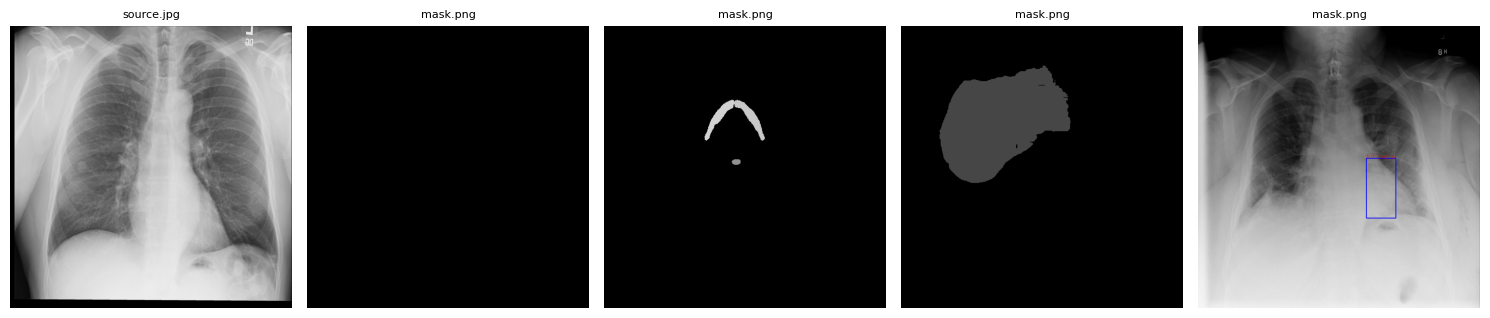

✅ Displayed 5 example images.


In [54]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# Use dataset-agnostic active image dir prepared in previous cell.
image_folder_path = ACTIVE_IMAGE_DIR if "ACTIVE_IMAGE_DIR" in globals() else LOCAL_IMAGE_DIR
print(f"Searching for images in: {image_folder_path}")

image_extensions = (".png", ".jpg", ".jpeg", ".gif", ".bmp", ".tiff")
all_image_files = []
for root, _, files in os.walk(image_folder_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            all_image_files.append(os.path.join(root, file))

if not all_image_files:
    print(f"⚠️ No images found in {image_folder_path}. Please check path/config.")
else:
    print(f"Found {len(all_image_files)} images.")
    num_examples = min(5, len(all_image_files))
    selected_images = random.sample(all_image_files, num_examples)

    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(selected_images):
        try:
            img = Image.open(img_path)
            plt.subplot(1, num_examples, i + 1)
            plt.imshow(img)
            plt.title(os.path.basename(img_path), fontsize=8)
            plt.axis("off")
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            plt.subplot(1, num_examples, i + 1)
            plt.text(0.5, 0.5, "Error", horizontalalignment="center", verticalalignment="center", transform=plt.gca().transAxes, color="red")
            plt.axis("off")

    plt.tight_layout()
    plt.show()
    print(f"✅ Displayed {num_examples} example images.")

In [55]:
# vqa_datasets __main__ test (runs the module exactly like a script)
import os
import sys
import subprocess

# Ensure we run from project root
os.chdir(DRIVE_PROJECT_PATH)
print(f"cwd: {os.getcwd()}")

# Use dataset-agnostic image dir
data_dir = DATA_DIR
image_dir = ACTIVE_IMAGE_DIR if "ACTIVE_IMAGE_DIR" in globals() else LOCAL_IMAGE_DIR
dataset_name = DATASET

cmd = [
    sys.executable,
    "-m",
    "diffuvqa.vqa_datasets",
    "--data_dir", data_dir,
    "--dataset", dataset_name,
    "--image_dir", image_dir,
    "--vocab", MODEL_NAME.lower(),
    "--config_name", "bert-base-uncased" if MODEL_NAME.lower() == "bert" else MODEL_NAME,
    "--batch_size", "1",
    "--seq_len", "64",
    "--image_size", "224",
]

print("Running command:")
print(" ".join(cmd))
print("-" * 80)

result = subprocess.run(cmd, text=True, capture_output=True)
print(result.stdout)
if result.stderr:
    print("[stderr]")
    print(result.stderr)

print("-" * 80)
print(f"Return code: {result.returncode}")
if result.returncode != 0:
    print("vqa_datasets __main__ test failed. Check logs above for missing path/dependency details.")
else:
    print("vqa_datasets __main__ test completed successfully.")

cwd: /content/drive/MyDrive/DiffuVQA
Running command:
/usr/bin/python3 -m diffuvqa.vqa_datasets --data_dir datasets --dataset SLAKE --image_dir /content/DiffuVQA/datasets/SLAKE/imgs/imgs --vocab pubmedbert --config_name pubmedbert --batch_size 1 --seq_len 64 --image_size 224
--------------------------------------------------------------------------------
save PubMedBERT tokenizer to diffuvqa/config
reload the random embeddings Embedding(28895, 1024)
Logging to /tmp/openai-2026-05-21-12-38-51-914868
##############################
Loading text data...
##############################
Loading dataset SLAKE from datasets...
### Loading from the TRAIN set...
### Data samples...
questions: ['What modality is used to take this image?', 'Which part of the body does this image belong to?'] answers: ['MRI', 'Abdomen'] images: ['imgs/xmlab1/source.jpg', 'imgs/xmlab1/source.jpg']
RAM used: 976.93 MB
Dataset size: 4919
Tokenized 512 / 4919 -- RAM: 987.53 MB
Tokenized 1024 / 4919 -- RAM: 992.58 MB
Tok

In [56]:
# Bağımlılıkları yükle
# Colab PyTorch ile geliyor, o yüzden requirements_colab.txt kullanıyoruz
!pip install --upgrade pip
!pip install -r requirements_colab.txt
!pip install pandas openpyxl bert-score  # Excel support ve BERTScore için
!python -m spacy download en_core_web_sm

print("\n✅ Kurulum tamamlandı!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 147.7 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

✅ Kurulum tamamlandı!


In [57]:
# Gerekli kütüphaneleri içe aktar
import os
import sys
import json
import torch
import pandas as pd
import numpy as np
from datetime import datetime
from collections import defaultdict
import glob

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
!pip install torchmetrics

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device: NVIDIA A100-SXM4-40GB


In [58]:
# Model ağırlıklarını HuggingFace'den cache'e al (hf-mirror weights servis etmiyor)
# Bu hücreyi training'den önce çalıştır.
# NeuML/pubmedbert-base-embeddings bir sentence-transformers modeli olduğundan
# BertModel.from_pretrained() ile yüklenemiyor. Doğru model Microsoft BiomedBERT.
import os
from transformers import BertModel, BertTokenizer, AutoTokenizer

_endpoint = os.environ.pop("HF_ENDPOINT", None)

print("BERT indiriliyor (bert-base-uncased)...")
BertTokenizer.from_pretrained("bert-base-uncased")
BertModel.from_pretrained("bert-base-uncased")
print("✅ BERT cache'e alındı.")

print("\nMicrosoft BiomedBERT indiriliyor (microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract)...")
AutoTokenizer.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract")
BertModel.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract")
print("✅ BiomedBERT cache'e alındı.")

if _endpoint:
    os.environ["HF_ENDPOINT"] = _endpoint

print("\n✅ Tüm model ağırlıkları cache'e alındı, training başlayabilir.")

BERT indiriliyor (bert-base-uncased)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BERT cache'e alındı.

Microsoft BiomedBERT indiriliyor (microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BiomedBERT cache'e alındı.

✅ Tüm model ağırlıkları cache'e alındı, training başlayabilir.


## 2. Model Eğitimi


In [ ]:
import os
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

train_image_dir = ACTIVE_IMAGE_DIR if "ACTIVE_IMAGE_DIR" in globals() else LOCAL_IMAGE_DIR
print(f"Training with image_dir: {train_image_dir}")

resume_flag = f"--resume_checkpoint {RESUME_CHECKPOINT}" if RESUME_CHECKPOINT else ""
print(f"Resume Flag {resume_flag}")
!python train.py \
    --vocab {MODEL_NAME.lower()} \
    --use_plm_init {MODEL_NAME} \
    --batch_size {BATCH_SIZE} \
    --microbatch {MICROBATCH} \
    --lr {LR} \
    --diffusion_steps {DIFFUSION_STEPS} \
    --seq_len {SEQ_LEN} \
    --hidden_t_dim {HIDDEN_T_DIM} \
    --checkpoint_path {CHECKPOINT_PATH} \
    --seed {SEED} \
    --learning_steps {LEARNING_STEPS} \
    --save_interval {SAVE_INTERVAL} \
    --log_interval {LOG_INTERVAL} \
    --eval_interval 500 \
    --data_dir {DATA_DIR} \
    --dataset {DATASET} \
    --image_dir {train_image_dir} \
    --use_noising_f {USE_NOISING_F} \
    --pre_answer_loss_weight {PRE_ANSWER_LOSS_WEIGHT} \
    {resume_flag}


Training with image_dir: /content/DiffuVQA/datasets/SLAKE/imgs/imgs
Resume Flag --resume_checkpoint /content/drive/MyDrive/DiffuVQA/checkpoints/slake/pubmedbert/btch64/lr0.000283/ema_0.9999_095000.pt
save PubMedBERT tokenizer to /content/drive/MyDrive/DiffuVQA/checkpoints/slake/pubmedbert/btch64/lr0.000283
reload the random embeddings Embedding(28895, 768)
initializing from pretrained PubMedBERT (medical domain)...
BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.2,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "tie_word_embeddings": true,
  "transformers_versi

## 3. Model Örnekleme (Inference)

In [59]:
import glob

# User specified resume checkpoint will be used for inference
checkpoint_file = RESUME_CHECKPOINT
SAMPLE_SEED2 = 102  # Changed to 102 to match the existing file on Drive

if checkpoint_file:
    print(f"📂 Kullanılacak checkpoint: {checkpoint_file}")
else:
    print("⚠️ Checkpoint bulunamadı! Lütfen eğitimi tamamlayın veya RESUME_CHECKPOINT'i ayarlayın.")

if checkpoint_file:
    !python sample_vqa_GPU.py \
        --model_path {checkpoint_file} \
        --step {SAMPLE_STEP} \
        --batch_size {BATCH_SIZE} \
        --seed2 {SAMPLE_SEED2} \
        --split test \
        --out_dir {SAMPLE_FOLDER} \
        --clamp_step 0

    print(f"\n✅ Örnekleme tamamlandı!")
    print(f"📂 Çıktı dosyaları {SAMPLE_FOLDER} klasöründe oluşturuldu.")
    !echo "\n📄 Oluşturulan sample dosyaları:"
    !ls -lh {SAMPLE_FOLDER}/*.jsonl | tail -5

📂 Kullanılacak checkpoint: /content/drive/MyDrive/DiffuVQA/checkpoints/slake/pubmedbert/btch64/lr0.000283/ema_0.9999_225000.pt
Logging to /tmp/openai-2026-05-21-12-39-27-170579
DEBUG: Parsed model_path = /content/drive/MyDrive/DiffuVQA/checkpoints/slake/pubmedbert/btch64/lr0.000283/ema_0.9999_225000.pt
### Loading model from /content/drive/MyDrive/DiffuVQA/checkpoints/slake/pubmedbert/btch64/lr0.000283/ema_0.9999_225000.pt
config_path: /content/drive/MyDrive/DiffuVQA/checkpoints/slake/pubmedbert/btch64/lr0.000283/training_args.json
### Updated args: Namespace(model_path='/content/drive/MyDrive/DiffuVQA/checkpoints/slake/pubmedbert/btch64/lr0.000283/ema_0.9999_225000.pt', step=200, out_dir='/content/drive/MyDrive/DiffuVQA/samples/slake/pubmedbert', top_p=0, lr=0.000283, batch_size=64, learning_steps=250000, microbatch=16, log_interval=100, save_interval=5000, eval_interval=500, valid=True, ema_rate='0.9999', resume_checkpoint='/content/drive/MyDrive/DiffuVQA/checkpoints/slake/pubmedbert

## 4. Model Değerlendirme ve CSV Export

In [60]:
# İlk olarak eval/eval_DiffuVQA.py ile değerlendir.
import glob, json, os

# Use the same checkpoint file as used for sampling
_ckpt_name = os.path.basename(checkpoint_file)
CURRENT_SAMPLE_FILENAME = f"{_ckpt_name}.seed{SAMPLE_SEED2}_step0_samplestep{SAMPLE_STEP}_bsize{BATCH_SIZE}.jsonl"

print(f"📄 Değerlendirilecek dosya: {CURRENT_SAMPLE_FILENAME}")

# Data leakage kontrolü: generate_answer == reference_answer ise eski kodla üretilmiş demektir
sample_path = os.path.join(SAMPLE_FOLDER, CURRENT_SAMPLE_FILENAME)
if os.path.exists(sample_path):
    with open(sample_path) as f:
        rows = [json.loads(l) for l in f][:5]
    print("\n🔍 Data leakage kontrolü (ilk 5 örnek):")
    for i, r in enumerate(rows):
        gen = r.get('generate_answer', '')
        ref = r.get('reference_answer', '')
        match = "⚠️ AYNI" if gen.strip() == ref.strip() else "✅ FARKLI"
        print(f"  [{i+1}] {match} | ref: '{ref}' | gen: '{gen}'")

!python eval/eval_DiffuVQA.py --folder {SAMPLE_FOLDER} --filename {CURRENT_SAMPLE_FILENAME}

📄 Değerlendirilecek dosya: ema_0.9999_225000.pt.seed105_step0_samplestep200_bsize64.jsonl
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
Enhanced metrics loaded successfully!
Excel export module loaded successfully!
save PubMedBERT tokenizer to diffuvqa/config
/content/drive/MyDrive/DiffuVQA/samples/slake/pubmedbert
Traceback (most recent call last):
  File "/content/drive/MyDrive/DiffuVQA/eval/eval_DiffuVQA.py", line 219, in <module>
    with open(files[0], 'r') as f:
         ^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Diff

In [ ]:
# Değerlendirme fonksiyonları
from torchmetrics.text.rouge import ROUGEScore
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk

# NLTK veri setlerini indir
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

rougeScore = ROUGEScore()

def get_bleu(recover, reference, n=1):
    """BLEU-n score"""
    weights = tuple((1.0 / n for _ in range(n)))
    return sentence_bleu([reference.split()], recover.split(),
                        weights=weights,
                        smoothing_function=SmoothingFunction().method4)

def rouge_l_score(prediction, reference):
    """ROUGE-L score"""
    scores = rougeScore(prediction, reference)
    return scores['rougeL_fmeasure'].item()

def calculate_meteor(prediction, reference):
    """METEOR score"""
    return meteor_score([word_tokenize(reference)], word_tokenize(prediction))

def cider_score(predictions, references):
    """CIDEr-like score using TF-IDF cosine similarity"""
    if not predictions or not references:
        return 0.0
    try:
        vectorizer = TfidfVectorizer()
        tfidf_matrix = vectorizer.fit_transform(predictions + references)
        n_pred = len(predictions)
        pred_vectors = tfidf_matrix[:n_pred]
        ref_vectors = tfidf_matrix[n_pred:]
        similarities = cosine_similarity(pred_vectors, ref_vectors)
        return similarities.diagonal().mean()
    except:
        return 0.0

print("✅ Değerlendirme fonksiyonları hazır")


✅ Değerlendirme fonksiyonları hazır


In [ ]:
def evaluate_and_export_csv(sample_files, output_csv="evaluation_results.csv", dataset_file="datasets/test.jsonl",
                            model_label="DiffuVQA", dataset_label="SLAKE"):
    if isinstance(sample_files, str):
        sample_files = [sample_files]

    print(f"📂 Dataset'ten answer_type bilgisi yükleniyor: {dataset_file}")
    answer_type_map = {}
    try:
        with open(dataset_file, 'r', encoding='utf-8') as f:
            for line in f:
                data = json.loads(line)
                qid = data.get('qid')
                question = data.get('question', '').strip().lower()
                answer_type = data.get('answer_type', 'UNKNOWN')
                if qid:
                    answer_type_map[qid] = answer_type
                if question:
                    answer_type_map[question] = answer_type
        print(f"✅ {len(answer_type_map)} answer_type mapping yüklendi")
    except Exception as e:
        print(f"⚠️ Dataset yüklenemedi: {e}")
        answer_type_map = {}

    all_results = []

    for sample_file in sample_files:
        print(f"\n📊 Değerlendiriliyor: {sample_file}")

        samples = []
        with open(sample_file, 'r', encoding='utf-8') as f:
            for line in f:
                samples.append(json.loads(line))
        print(f"✅ {len(samples)} satır okundu")

        bleu1_scores = []
        rougeL_scores = []
        meteor_scores = []
        f1_scores = []
        predictions = []
        references = []

        total_samples = 0
        correct_all = 0
        correct_yn = 0
        correct_oe = 0
        count_yn = 0
        count_oe = 0
        empty_count = 0

        for sample in samples:
            pred = (sample.get('generate_answer') or
                   sample.get('recover') or
                   sample.get('generated_answer') or
                   sample.get('prediction') or '').strip()
            ref = (sample.get('reference_answer') or
                  sample.get('reference') or
                  sample.get('answer') or '').strip()
            q_type = sample.get('answer_type', 'UNKNOWN')
            if q_type == 'UNKNOWN':
                qid = sample.get('qid')
                question = sample.get('question', '').strip().lower()
                if qid and qid in answer_type_map:
                    q_type = answer_type_map[qid]
                elif question and question in answer_type_map:
                    q_type = answer_type_map[question]
            if not ref:
                continue
            if not pred:
                empty_count += 1
                pred = "[EMPTY]"

            predictions.append(pred)
            references.append(ref)
            em = 1.0 if pred.lower().strip() == ref.lower().strip() else 0.0
            total_samples += 1
            if em == 1.0:
                correct_all += 1
                if q_type == 'CLOSED':
                    correct_yn += 1
                elif q_type == 'OPEN':
                    correct_oe += 1
            if q_type == 'CLOSED':
                count_yn += 1
            elif q_type == 'OPEN':
                count_oe += 1

            if pred != "[EMPTY]":
                pred_tokens = set(pred.lower().split())
                ref_tokens = set(ref.lower().split())
                if len(pred_tokens) == 0 or len(ref_tokens) == 0:
                    f1 = 0.0
                else:
                    precision = len(pred_tokens & ref_tokens) / len(pred_tokens)
                    recall = len(pred_tokens & ref_tokens) / len(ref_tokens)
                    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
                f1_scores.append(f1)
            else:
                f1_scores.append(0.0)

            bleu1_scores.append(get_bleu(pred, ref, n=1) if pred != "[EMPTY]" else 0.0)
            rougeL_scores.append(rouge_l_score(pred, ref) if pred != "[EMPTY]" else 0.0)
            meteor_scores.append(calculate_meteor(pred, ref) if pred != "[EMPTY]" else 0.0)

        cider = cider_score(predictions, references) if predictions else 0.0

        print("⏳ BERTScore hesaplanıyor...")
        bert_f1_score = 0.0
        try:
            import warnings, logging
            from bert_score import score as bert_score_fn
            valid_preds = [p for p in predictions if p != "[EMPTY]"]
            valid_refs = [r for i, r in enumerate(references) if predictions[i] != "[EMPTY]"]
            if valid_preds and valid_refs:
                # Suppress transformers weight-loading noise (LOAD REPORT, position_ids warnings)
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    logging.disable(logging.WARNING)
                    bert_precision, bert_recall, bert_f1 = bert_score_fn(
                        valid_preds, valid_refs,
                        lang='en', verbose=False,
                        device='cuda' if torch.cuda.is_available() else 'cpu'
                    )
                    logging.disable(logging.NOTSET)
                bert_f1_score = bert_f1.mean().item()
        except Exception as e:
            print(f"⚠️ BERTScore hesaplanamadı: {e}")

        print(f"\n📋 Answer Type Dağılımı:")
        print(f"  CLOSED sorular: {count_yn}")
        print(f"  OPEN sorular: {count_oe}")
        print(f"  UNKNOWN: {total_samples - count_yn - count_oe}")

        sample_folder_path = os.path.dirname(sample_file) if os.path.dirname(sample_file) else "./samples"
        results = {
            'model_name': model_label,
            'dataset_name': dataset_label,
            'export_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'overall_accuracy': correct_all / total_samples if total_samples > 0 else 0.0,
            'yes_no_accuracy': correct_yn / count_yn if count_yn > 0 else 0.0,
            'open_ended_accuracy': correct_oe / count_oe if count_oe > 0 else 0.0,
            'bleu_1_score': np.mean(bleu1_scores) if bleu1_scores else 0.0,
            'rouge_l_score': np.mean(rougeL_scores) if rougeL_scores else 0.0,
            'meteor_score': np.mean(meteor_scores) if meteor_scores else 0.0,
            'cider_score': cider,
            'bert_score': bert_f1_score,
            'f1_score': np.mean(f1_scores) if f1_scores else 0.0,
            'additional_info': f"Empty: {empty_count} ({100*empty_count/total_samples:.1f}%)" if total_samples > 0 else "",
            'Sample Folder': sample_folder_path,
            'Total Samples': total_samples,
            'Evaluation Date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'File Count': 1
        }
        all_results.append(results)

        print(f"\n📈 Sonuçlar - {os.path.basename(sample_file)}:")
        print(f"  Total Samples: {results['Total Samples']}")
        print(f"  Overall Accuracy: {results['overall_accuracy']:.4f}")
        print(f"  Yes/No Accuracy: {results['yes_no_accuracy']:.4f}")
        print(f"  Open-Ended Accuracy: {results['open_ended_accuracy']:.4f}")
        print(f"  F1 Score: {results['f1_score']:.4f}")
        print(f"  BLEU-1: {results['bleu_1_score']:.4f}")
        print(f"  ROUGE-L: {results['rouge_l_score']:.4f}")
        print(f"  METEOR: {results['meteor_score']:.4f}")
        print(f"  CIDEr: {results['cider_score']:.4f}")
        print(f"  BERTScore: {results['bert_score']:.4f}")

    df = pd.DataFrame(all_results)
    df.to_csv(output_csv, index=False, encoding='utf-8')
    print(f"\n✅ Sonuçlar CSV'ye kaydedildi: {output_csv}")
    return df

print("✅ CSV export fonksiyonu hazır")


✅ CSV export fonksiyonu hazır


In [ ]:
# Yalnızca son oluşturulan örnek dosyasını değerlendir
sample_files = [os.path.join(SAMPLE_FOLDER, CURRENT_SAMPLE_FILENAME)]

os.makedirs("./reports", exist_ok=True)

if not sample_files or not os.path.exists(sample_files[0]):
    print("⚠️ Örnek dosyası bulunamadı!")
    print(f"💡 Lütfen önce örnekleme hücresini çalıştırın, beklenen dosya: {sample_files[0]}")
else:
    print(f"📂 {len(sample_files)} örnek dosyası bulundu")
    results_df = evaluate_and_export_csv(
        sample_files,
        output_csv=OUTPUT_CSV,
        model_label=MODEL_LABEL,
        dataset_label=DATASET,
    )
    print("\n" + "="*80)
    print("📊 TÜM SONUÇLAR:")
    print("="*80)
    display(results_df)

⚠️ Örnek dosyası bulunamadı!
💡 Lütfen önce örnekleme hücresini çalıştırın.
   Checkpoint: /content/drive/MyDrive/DiffuVQA/checkpoints/slake/pubmedbert/btch64/lr0.000283/ema_0.9999_*.pt


## 5. Sonuçları İndir

In [ ]:
# CSV dosyasını Google Drive'a kaydet ve indir
from google.colab import files

os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)

if os.path.exists(OUTPUT_CSV):
    shutil.copy(OUTPUT_CSV, DRIVE_RESULTS_PATH)
    print(f"✅ CSV Google Drive'a kaydedildi: {DRIVE_RESULTS_PATH}")
    files.download(OUTPUT_CSV)
    print(f"✅ {OUTPUT_CSV} bilgisayarınıza indirildi")
else:
    print(f"⚠️ CSV dosyası bulunamadı: {OUTPUT_CSV}")
    print("💡 Lütfen önce değerlendirme hücresini çalıştırın.")

# Checkpoint'leri de Drive'a yedekle (opsiyonel)
print("\n💾 Checkpoint'leri yedeklemek ister misiniz?")
print(f"   # !cp -r {CHECKPOINT_PATH} /content/drive/MyDrive/DiffuVQA_Checkpoints/")


⚠️ CSV dosyası bulunamadı: ./reports/pubmedbert_slake_evaluation_results.csv
💡 Lütfen önce değerlendirme hücresini çalıştırın.

💾 Checkpoint'leri yedeklemek ister misiniz?
   # !cp -r /content/drive/MyDrive/DiffuVQA/checkpoints/slake/pubmedbert/btch64/lr0.000283 /content/drive/MyDrive/DiffuVQA_Checkpoints/


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sonuçları görselleştir
if 'results_df' in locals() and len(results_df) > 0:
    # Metrik sütunlarını seç
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Accuracy metrikleri (CLOSED ve OPEN)
    accuracy_cols = ['overall_accuracy', 'yes_no_accuracy', 'open_ended_accuracy']
    results_df[accuracy_cols].iloc[0].plot(kind='bar', ax=axes[0], color='skyblue')
    axes[0].set_title('Accuracy Metrics (CLOSED=Yes/No, OPEN=Open-Ended)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Score', fontsize=12)
    axes[0].set_ylim([0, 1])
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

    # NLG ve Semantic metrikleri
    nlg_cols = ['f1_score', 'bleu_1_score', 'rouge_l_score', 'meteor_score', 'cider_score', 'bert_score']
    results_df[nlg_cols].iloc[0].plot(kind='bar', ax=axes[1], color='lightcoral')
    axes[1].set_title('NLG & Semantic Similarity Metrics', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].set_ylim([0, 1])
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig('./reports/metrics_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Görselleştirme kaydedildi: ./reports/metrics_visualization.png")
else:
    print("⚠️ Görselleştirme için sonuç bulunamadı.")
    print("💡 Lütfen önce değerlendirme hücresini (Cell 15) çalıştırın.")

⚠️ Görselleştirme için sonuç bulunamadı.
💡 Lütfen önce değerlendirme hücresini (Cell 15) çalıştırın.
